# Micro Proyecto 1 — Generación de Música con LSTM
Compositor seleccionado: **Mozart**

In [1]:
import pretty_midi
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pygame
import time

pygame 2.6.1 (SDL 2.28.4, Python 3.11.13)
Hello from the pygame community. https://www.pygame.org/contribute.html


/opt/anaconda3/envs/master/lib/python3.11/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


## 1. Leer los archivos MIDI de Mozart

In [2]:
DATA_PATH = './data/music_artist/mozart'

midi_files = sorted([os.path.join(DATA_PATH, f) for f in os.listdir(DATA_PATH) if f.endswith('.mid')])
print(f'Archivos encontrados: {len(midi_files)}')
for i, f in enumerate(midi_files):
    print(f'  [{i}] {os.path.basename(f)}')

Archivos encontrados: 21
  [0] mz_311_1.mid
  [1] mz_311_2.mid
  [2] mz_311_3.mid
  [3] mz_330_1.mid
  [4] mz_330_2.mid
  [5] mz_330_3.mid
  [6] mz_331_1.mid
  [7] mz_331_2.mid
  [8] mz_331_3.mid
  [9] mz_332_1.mid
  [10] mz_332_2.mid
  [11] mz_332_3.mid
  [12] mz_333_1.mid
  [13] mz_333_2.mid
  [14] mz_333_3.mid
  [15] mz_545_1.mid
  [16] mz_545_2.mid
  [17] mz_545_3.mid
  [18] mz_570_1.mid
  [19] mz_570_2.mid
  [20] mz_570_3.mid


## 2. Escuchar un archivo

In [3]:
def play_midi(filepath, seconds=15):
    """Reproduce un archivo MIDI durante 'seconds' segundos."""
    pygame.mixer.init()
    pygame.mixer.music.load(filepath)
    pygame.mixer.music.play()
    print(f'Reproduciendo: {os.path.basename(filepath)} ({seconds}s)...')
    time.sleep(seconds)
    pygame.mixer.music.stop()
    print('Listo.')

# Escuchar los primeros 15 segundos del primer archivo
play_midi(midi_files[0], seconds=15)

Reproduciendo: mz_311_1.mid (15s)...
Listo.


## 3. Explorar un archivo

In [4]:
pm = pretty_midi.PrettyMIDI(midi_files[0])

print(f'Archivo: {os.path.basename(midi_files[0])}')
print(f'Duración: {pm.get_end_time():.2f} segundos')
print(f'Número de instrumentos: {len(pm.instruments)}')

for i, instrument in enumerate(pm.instruments):
    instrument_name = pretty_midi.program_to_instrument_name(instrument.program)
    print(f'  Instrumento {i}: {instrument_name} — {len(instrument.notes)} notas')

Archivo: mz_311_1.mid
Duración: 700.88 segundos
Número de instrumentos: 2
  Instrumento 0: Acoustic Grand Piano — 1517 notas
  Instrumento 1: Acoustic Grand Piano — 1453 notas


In [5]:
instrument = pm.instruments[0]
instrument_name = pretty_midi.program_to_instrument_name(instrument.program)
print(f'Instrumento: {instrument_name}')
print(f'\nPrimeras 10 notas:')
print(f'{"pitch":>8} {"start":>8} {"end":>8} {"duration":>10} {"velocity":>10}')
for note in instrument.notes[:10]:
    duration = note.end - note.start
    print(f'{note.pitch:>8} {note.start:>8.3f} {note.end:>8.3f} {duration:>10.3f} {note.velocity:>10}')

Instrumento: Acoustic Grand Piano

Primeras 10 notas:
   pitch    start      end   duration   velocity
      66    0.000    0.423      0.423         60
      74    0.000    0.423      0.423         73
      69    0.000    0.423      0.423         60
      79    0.846    0.958      0.112         66
      78    0.948    1.059      0.112         55
      76    1.049    1.161      0.112         54
      78    1.150    1.262      0.112         54
      81    1.252    1.364      0.112         65
      79    1.353    1.466      0.113         55
      78    1.455    1.576      0.121         55


## 4. Extraer las características de todos los archivos

Por cada nota extraemos:
- **pitch**: nota musical (categórica)
- **step**: tiempo desde la nota anterior (start_actual - start_anterior)
- **duration**: duración de la nota (end - start)
- **velocity**: velocidad de la nota (numérica)

In [6]:
def extract_notes(midi_file):
    pm = pretty_midi.PrettyMIDI(midi_file)
    instrument = pm.instruments[0]
    notes = sorted(instrument.notes, key=lambda x: x.start)
    
    rows = []
    prev_start = None
    for note in notes:
        duration = note.end - note.start
        step = note.start - prev_start if prev_start is not None else 0.0
        rows.append({
            'pitch': note.pitch,
            'step': step,
            'duration': duration,
            'velocity': note.velocity
        })
        prev_start = note.start
    return rows

all_notes = []
for f in midi_files:
    notes = extract_notes(f)
    all_notes.extend(notes)
    print(f'{os.path.basename(f)}: {len(notes)} notas')

df = pd.DataFrame(all_notes)
print(f'\nTotal de notas: {len(df)}')
df.head(10)

mz_311_1.mid: 1517 notas
mz_311_2.mid: 953 notas
mz_311_3.mid: 2041 notas
mz_330_1.mid: 2746 notas
mz_330_2.mid: 823 notas
mz_330_3.mid: 2270 notas
mz_331_1.mid: 3683 notas
mz_331_2.mid: 1630 notas
mz_331_3.mid: 1512 notas
mz_332_1.mid: 2952 notas
mz_332_2.mid: 732 notas
mz_332_3.mid: 3584 notas
mz_333_1.mid: 3344 notas
mz_333_2.mid: 1599 notas
mz_333_3.mid: 1962 notas
mz_545_1.mid: 1360 notas
mz_545_2.mid: 805 notas
mz_545_3.mid: 543 notas
mz_570_1.mid: 2318 notas
mz_570_2.mid: 1014 notas
mz_570_3.mid: 1157 notas

Total de notas: 38545


,pitch,step,duration,velocity
0,66,0.000000,0.423042,60
1,74,0.000000,0.423042,73
2,69,0.000000,0.423042,60
3,79,0.846084,0.111615,66
4,78,0.101468,0.111615,55
5,76,0.101468,0.111615,54
6,78,0.101468,0.111615,54
7,81,0.101468,0.111615,65
8,79,0.101468,0.112511,55
9,78,0.101468,0.121475,55


## 5. Estadísticas básicas

In [7]:
print('Estadísticas del dataset:')
print(df.describe())
print(f'\nPitch único: {df["pitch"].nunique()} valores distintos')
print(f'Pitch min: {df["pitch"].min()}, max: {df["pitch"].max()}')

Estadísticas del dataset:
              pitch          step      duration      velocity
count  38545.000000  38545.000000  38545.000000  38545.000000
mean      74.126553      0.219135      0.237060     57.234842
std        6.194095      0.264092      0.259454     11.952000
min       40.000000      0.000000      0.003759     21.000000
25%       70.000000      0.096320      0.102740     49.000000
50%       74.000000      0.118045      0.124689     56.000000
75%       79.000000      0.247934      0.265816     65.000000
max       91.000000      6.539590      6.642802    110.000000

Pitch único: 46 valores distintos
Pitch min: 40, max: 91


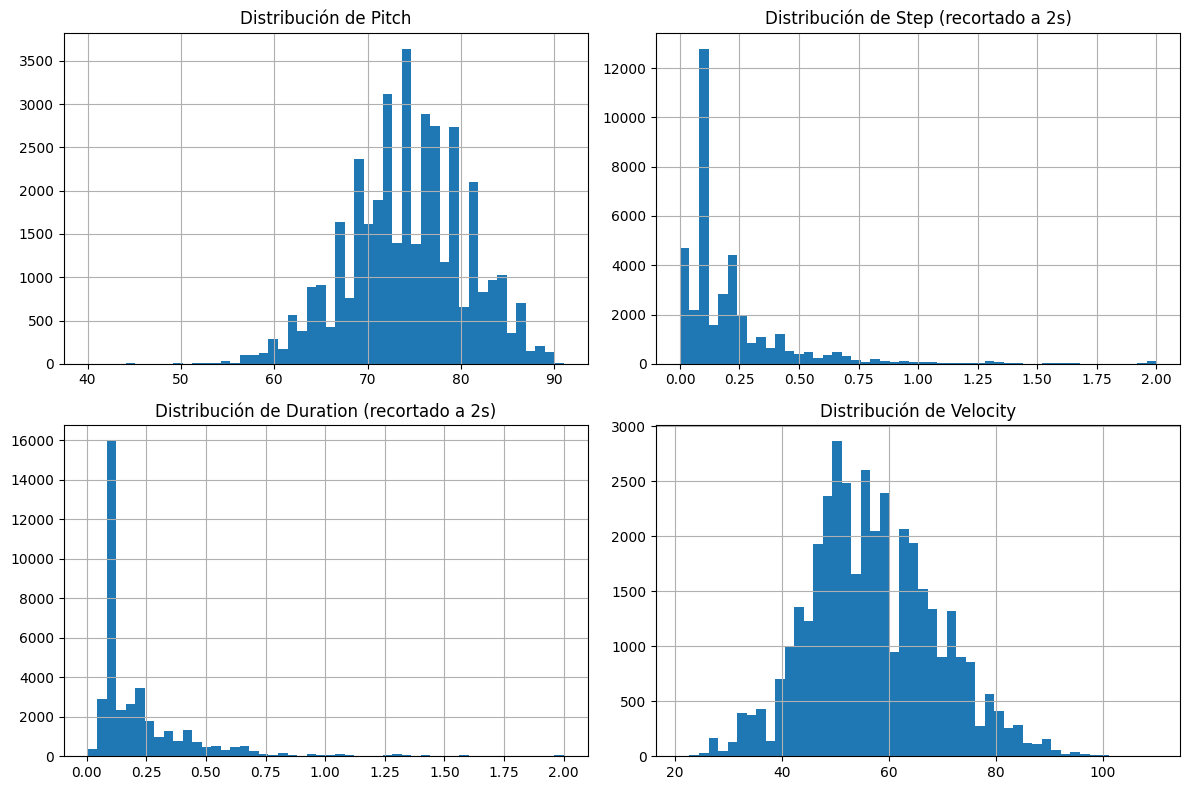

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

df['pitch'].hist(ax=axes[0,0], bins=50)
axes[0,0].set_title('Distribución de Pitch')

df['step'].clip(0, 2).hist(ax=axes[0,1], bins=50)
axes[0,1].set_title('Distribución de Step (recortado a 2s)')

df['duration'].clip(0, 2).hist(ax=axes[1,0], bins=50)
axes[1,0].set_title('Distribución de Duration (recortado a 2s)')

df['velocity'].hist(ax=axes[1,1], bins=50)
axes[1,1].set_title('Distribución de Velocity')

plt.tight_layout()
plt.show()